# 1-Libs

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


# 2-Explore Data

In [57]:
DATA_DIR = 'Data/'

de_gr = pd.read_excel(DATA_DIR + 'Telco_customer_churn_demographics.xlsx')
loc = pd.read_excel(DATA_DIR + 'Telco_customer_churn_location.xlsx')
pop = pd.read_excel(DATA_DIR + 'Telco_customer_churn_population.xlsx')
serv = pd.read_excel(DATA_DIR + 'Telco_customer_churn_services.xlsx')
stat = pd.read_excel(DATA_DIR + 'Telco_customer_churn_status.xlsx')


In [58]:
pd.set_option('display.max_columns', None)


## Status

In [59]:
stat.head()


,Status ID,Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,SWSORB1252,8779-QRDMV,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,SNAEQA8572,7495-OOKFY,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,LMBQNN3714,1658-BYGOY,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,VRZYZI9978,4598-XLKNJ,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,FDNAKX1688,4846-WHAFZ,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [60]:
stat.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Status ID           7043 non-null   str  
 1   Customer ID         7043 non-null   str  
 2   Count               7043 non-null   int64
 3   Quarter             7043 non-null   str  
 4   Satisfaction Score  7043 non-null   int64
 5   Customer Status     7043 non-null   str  
 6   Churn Label         7043 non-null   str  
 7   Churn Value         7043 non-null   int64
 8   Churn Score         7043 non-null   int64
 9   CLTV                7043 non-null   int64
 10  Churn Category      1869 non-null   str  
 11  Churn Reason        1869 non-null   str  
dtypes: int64(5), str(7)
memory usage: 660.4 KB


In [61]:
stat.isnull().sum().sort_values(ascending=False).head(10)


Churn Reason          5174
Churn Category        5174
Status ID                0
Customer ID              0
Quarter                  0
Count                    0
Satisfaction Score       0
Customer Status          0
Churn Value              0
Churn Label              0
dtype: int64

## Demographics

In [62]:
de_gr.head()


,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1


In [63]:
de_gr.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer ID           7043 non-null   str  
 1   Count                 7043 non-null   int64
 2   Gender                7043 non-null   str  
 3   Age                   7043 non-null   int64
 4   Under 30              7043 non-null   str  
 5   Senior Citizen        7043 non-null   str  
 6   Married               7043 non-null   str  
 7   Dependents            7043 non-null   str  
 8   Number of Dependents  7043 non-null   int64
dtypes: int64(3), str(6)
memory usage: 495.3 KB


## Location

In [64]:
loc.head()


,Location ID,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,OXCZEW7397,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,FCCECI8494,7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,HEHUQY7254,1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,WIUHRF2613,4598-XLKNJ,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,CFEZBF4415,4846-WHAFZ,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


In [65]:
loc.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Location ID  7043 non-null   str    
 1   Customer ID  7043 non-null   str    
 2   Count        7043 non-null   int64  
 3   Country      7043 non-null   str    
 4   State        7043 non-null   str    
 5   City         7043 non-null   str    
 6   Zip Code     7043 non-null   int64  
 7   Lat Long     7043 non-null   str    
 8   Latitude     7043 non-null   float64
 9   Longitude    7043 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 550.4 KB


## Services

In [66]:
serv.head()


,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,IJKDQVSWH3522,8779-QRDMV,1,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,BFKMZJAIE2285,7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,EIMVJQBMT7187,1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,EROZQXDUU4979,4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,GEEYSJUHY6991,4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


In [67]:
serv.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Service ID                         7043 non-null   str    
 1   Customer ID                        7043 non-null   str    
 2   Count                              7043 non-null   int64  
 3   Quarter                            7043 non-null   str    
 4   Referred a Friend                  7043 non-null   str    
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              3166 non-null   str    
 8   Phone Service                      7043 non-null   str    
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     7043 non-null   str    
 11  Internet Service                   7043 non-null   str    
 12  Int

In [68]:
serv.isnull().sum().sort_values(ascending=False).head(10)


Offer                                3877
Internet Type                        1526
Service ID                              0
Quarter                                 0
Referred a Friend                       0
Customer ID                             0
Count                                   0
Tenure in Months                        0
Number of Referrals                     0
Avg Monthly Long Distance Charges       0
dtype: int64

## Population

In [69]:
pop.head()


,ID,Zip Code,Population
0,1,90001,54492
1,2,90002,44586
2,3,90003,58198
3,4,90004,67852
4,5,90005,43019


In [70]:
pop.info()


<class 'pandas.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          1671 non-null   int64
 1   Zip Code    1671 non-null   int64
 2   Population  1671 non-null   int64
dtypes: int64(3)
memory usage: 39.3 KB


## تجهيز ودمج الجداول

In [71]:
# دول اعمدة ثابتة/مش مفيدة هنشيلهم قبل الدمج علشان منكررش اعمدة
drop_cols_common = ['Count', 'Quarter']
de_gr = de_gr.drop(columns=[c for c in drop_cols_common if c in de_gr.columns])
loc = loc.drop(columns=[c for c in drop_cols_common if c in loc.columns])
serv = serv.drop(columns=[c for c in drop_cols_common if c in serv.columns])
stat = stat.drop(columns=[c for c in drop_cols_common if c in stat.columns])

loc = loc.drop(columns=['Country', 'State', 'Lat Long'])


In [72]:
# نوحد نوع الـ ID والـ Zip Code في كل الجداول عشان الدمج يبقى مظبوط
for t in [de_gr, loc, serv, stat]:
    t['Customer ID'] = t['Customer ID'].astype(str)

loc['Zip Code'] = loc['Zip Code'].astype(str)
pop['Zip Code'] = pop['Zip Code'].astype(str)


In [73]:
# الاعمدة المالية دي ممكن تتخزن كـ text في الملف الاصلي (مسافة فاضية للعملاء الجداد بدل رقم)
money_cols = [
    'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
    'Total Long Distance Charges', 'Total Revenue', 'Monthly Charge',
    'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges'
]
for col in money_cols:
    if col in serv.columns:
        serv[col] = pd.to_numeric(serv[col], errors='coerce')


In [74]:
# Population على مستوى Zip Code مش Customer، فبنجمعها لصف واحد لكل Zip Code
pop_agg = pop.groupby('Zip Code', as_index=False)['Population'].sum()


In [75]:
df = stat.merge(de_gr, on='Customer ID', how='left')
df = df.merge(loc, on='Customer ID', how='left')
df = df.merge(serv, on='Customer ID', how='left')
df = df.merge(pop_agg, on='Zip Code', how='left')
df.shape


(7043, 51)

# 3-Fill missing value

In [76]:
df.isnull().sum().sort_values(ascending=False).head(10)


Churn Reason          5174
Churn Category        5174
Offer                 3877
Internet Type         1526
Customer ID              0
Satisfaction Score       0
Churn Label              0
Churn Score              0
Churn Value              0
Customer Status          0
dtype: int64

In [77]:
# دول اعمدة بتتملى بس للعملاء الي عملوا Churn فعلا، فالفراغ هنا معناه العميل لسه معملش Churn
df['Churn Category'] = df['Churn Category'].fillna('No Churn')
df['Churn Reason'] = df['Churn Reason'].fillna('No Churn')


In [78]:
# العميل الي معندوش عرض ترويجي، والعميل الي اصلا مشترك مش في انترنت
df['Offer'] = df['Offer'].fillna('No Offer')
df['Internet Type'] = df['Internet Type'].fillna('No Internet Service')


In [79]:
# العميل اللي لسه Tenure = 0 (جديد) لسه معملوش اول فاتورة، فالفراغ هنا صفر منطقي مش قيمة ناقصة
money_cols = ['Total Charges', 'Total Refunds', 'Total Extra Data Charges',
              'Total Long Distance Charges', 'Total Revenue']
for col in money_cols:
    df[col] = df[col].fillna(0)


In [80]:
df['Population'] = df['Population'].fillna(df['Population'].median())


In [81]:
df.isnull().sum().sum()


np.int64(0)

# 4-Handling noisy data + Skewness

In [82]:
df.describe()


,Satisfaction Score,Churn Value,Churn Score,CLTV,Age,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Population
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,3.244924,0.265370,58.505040,4400.295755,46.509726,0.468692,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,22139.814568
std,1.201657,0.441561,21.170031,1183.057152,16.750352,0.962802,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,21152.174407
min,1.000000,0.000000,5.000000,2003.000000,19.000000,0.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,11.000000
25%,3.000000,0.000000,40.000000,3469.000000,32.000000,0.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,2344.000000
50%,3.000000,0.000000,61.000000,4527.000000,46.000000,0.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,17554.000000
75%,4.000000,1.000000,75.500000,5380.500000,60.000000,0.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,36125.000000
max,5.000000,1.000000,96.000000,6500.000000,80.000000,9.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,105285.000000


In [83]:
outlier_cols = [
    'Tenure in Months', 'Monthly Charge', 'Total Charges', 'Total Refunds',
    'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue',
    'Avg Monthly GB Download', 'CLTV', 'Population'
]


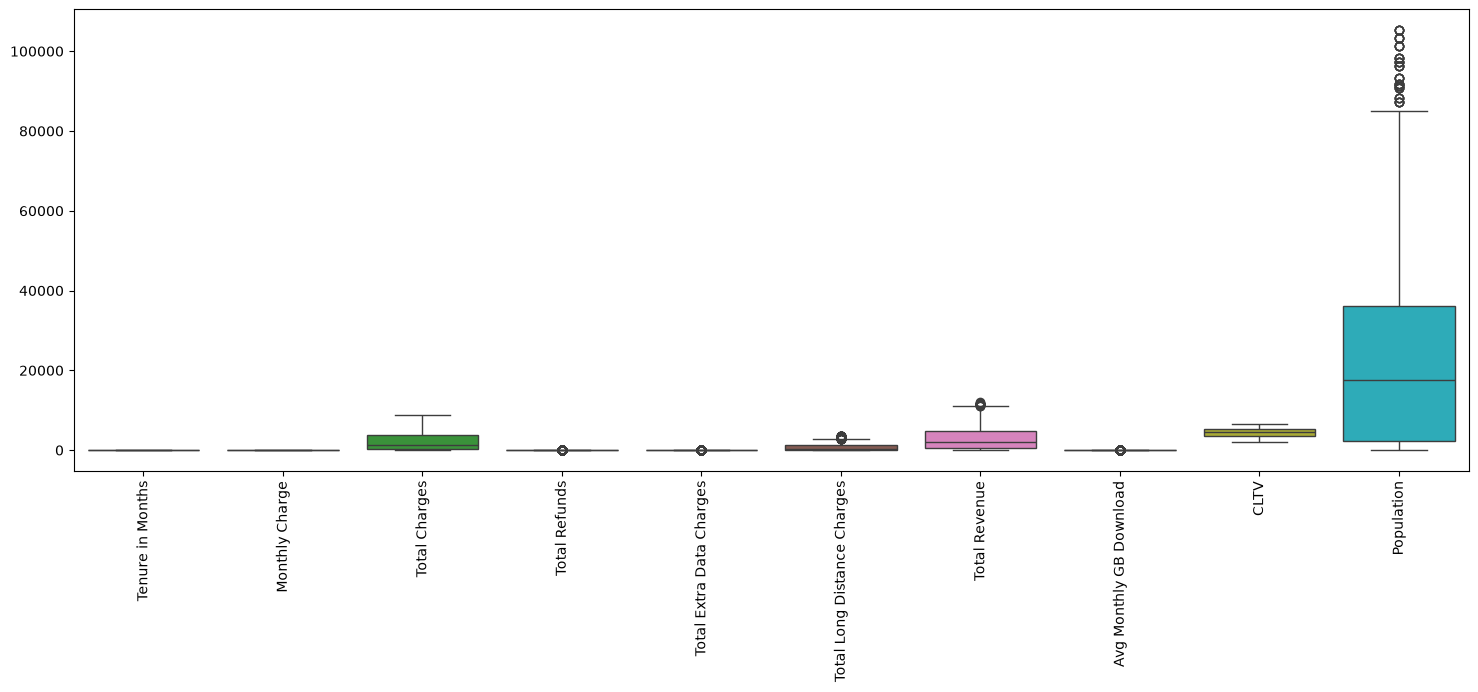

In [84]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[outlier_cols])
plt.xticks(rotation=90)
plt.show()


In [85]:
# بعض الاعمدة زي Total Refunds اغلبها صفر (IQR = صفر)، فلو عملنا clip عادي هنصفر اي قيمة غير الصفر بالغلط
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    upper_limit = q3 + 1.5 * iqr
    df[col] = df[col].clip(upper=upper_limit)


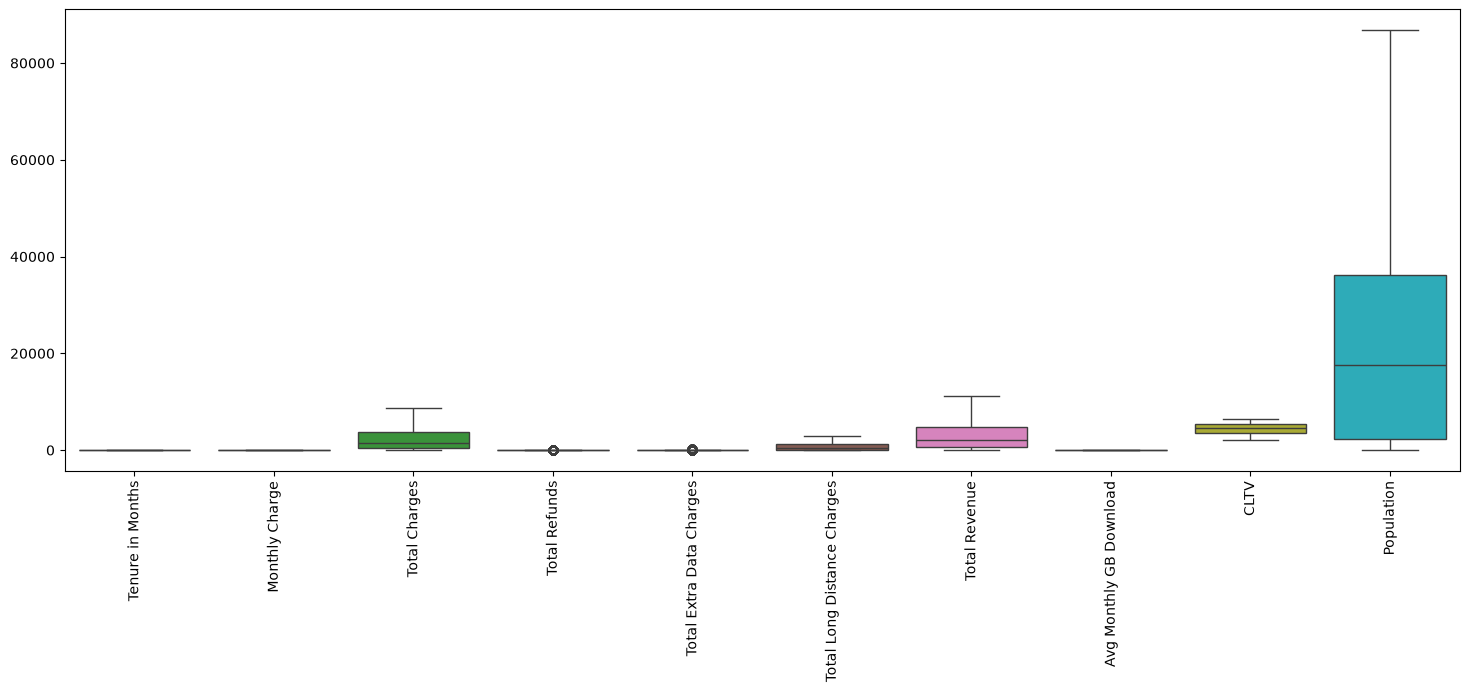

In [86]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[outlier_cols])
plt.xticks(rotation=90)
plt.show()


## Skewness

In [87]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
skewed_feats = df[numeric_cols].skew().sort_values(ascending=False)
skewed_feats.head(10)


Total Refunds                  4.328517
Total Extra Data Charges       4.091209
Number of Dependents           2.109932
Number of Referrals            1.446060
Total Long Distance Charges    1.133805
Churn Value                    1.063031
Total Charges                  0.963791
Avg Monthly GB Download        0.947686
Total Revenue                  0.913857
Population                     0.836820
dtype: float64

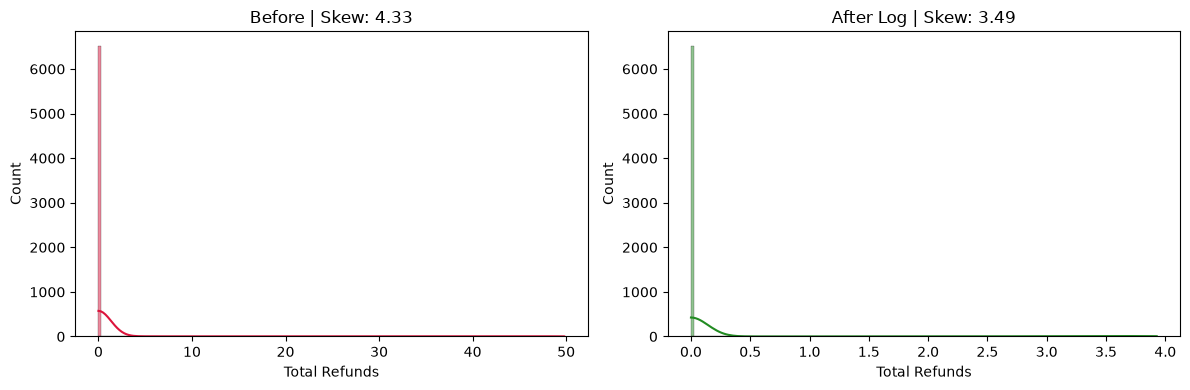

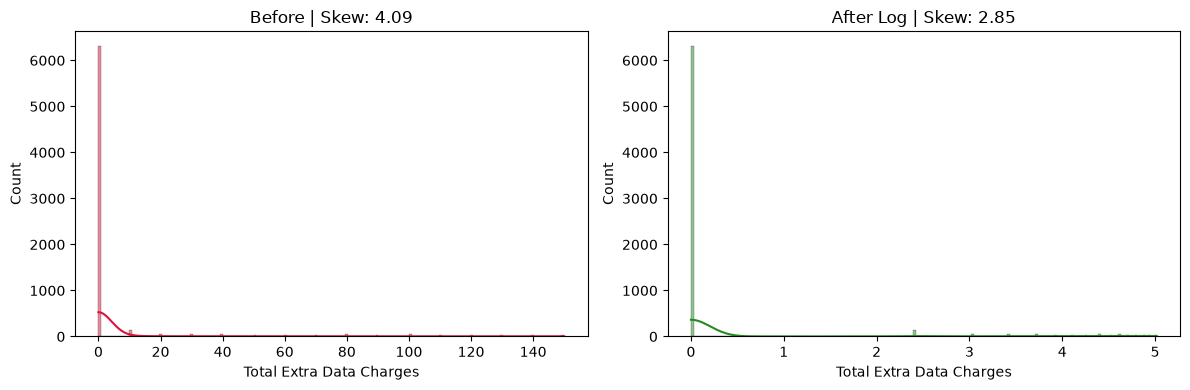

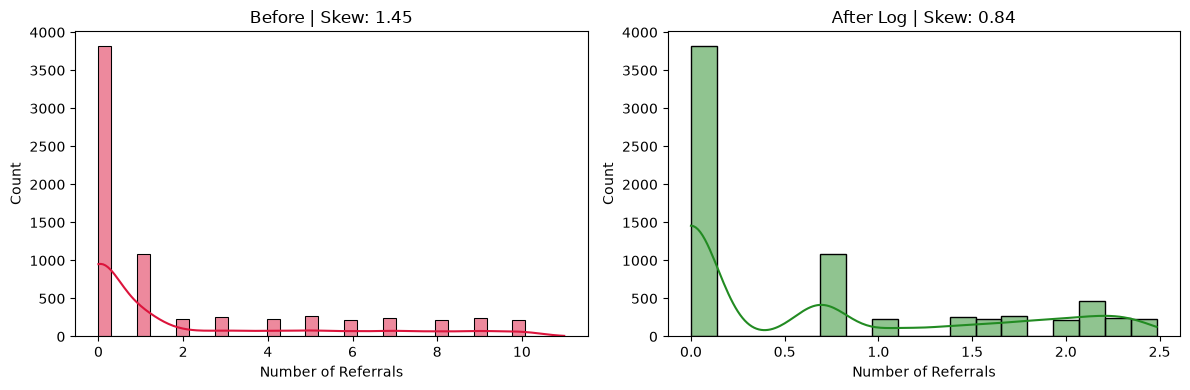

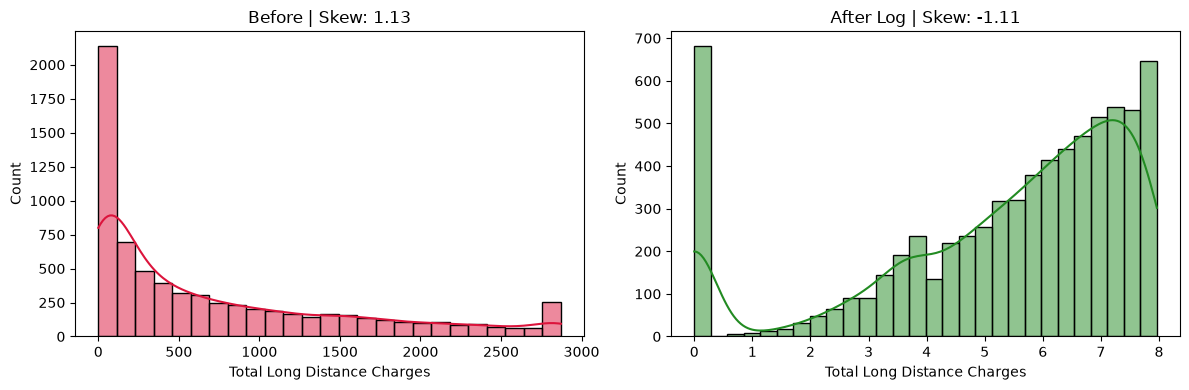

In [88]:
# بنشوف قبل وبعد Log Transform للمقارنة بس، من غير ما نسجل عمود جديد
# لان الداتا دي هتتصدر لـ SQL و Dashboard كمان مش بس للموديل، فلازم تفضل مفهومة
colms = ['Total Refunds', 'Total Extra Data Charges', 'Number of Referrals', 'Total Long Distance Charges']

for col in colms:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, color='crimson', ax=axes[0])
    axes[0].set_title(f'Before | Skew: {df[col].skew():.2f}')

    sns.histplot(np.log1p(df[col]), kde=True, color='forestgreen', ax=axes[1])
    axes[1].set_title(f'After Log | Skew: {np.log1p(df[col]).skew():.2f}')

    plt.tight_layout()
    plt.show()


# 5-Feature Engineering

In [89]:
service_cols = [
    'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data'
]
df['Total_Services_Subscribed'] = (df[service_cols] == 'Yes').sum(axis=1)


In [90]:
df['Net_Revenue'] = df['Total Revenue'] - df['Total Refunds']


In [91]:
df['Cost_Per_Service'] = df['Monthly Charge'] / (df['Total_Services_Subscribed'] + 1)


In [92]:
df['GB_Per_Tenure_Month'] = df['Avg Monthly GB Download'] / (df['Tenure in Months'] + 1)


# 6-Check Correlation

In [93]:
corr = df.corr(numeric_only=True)


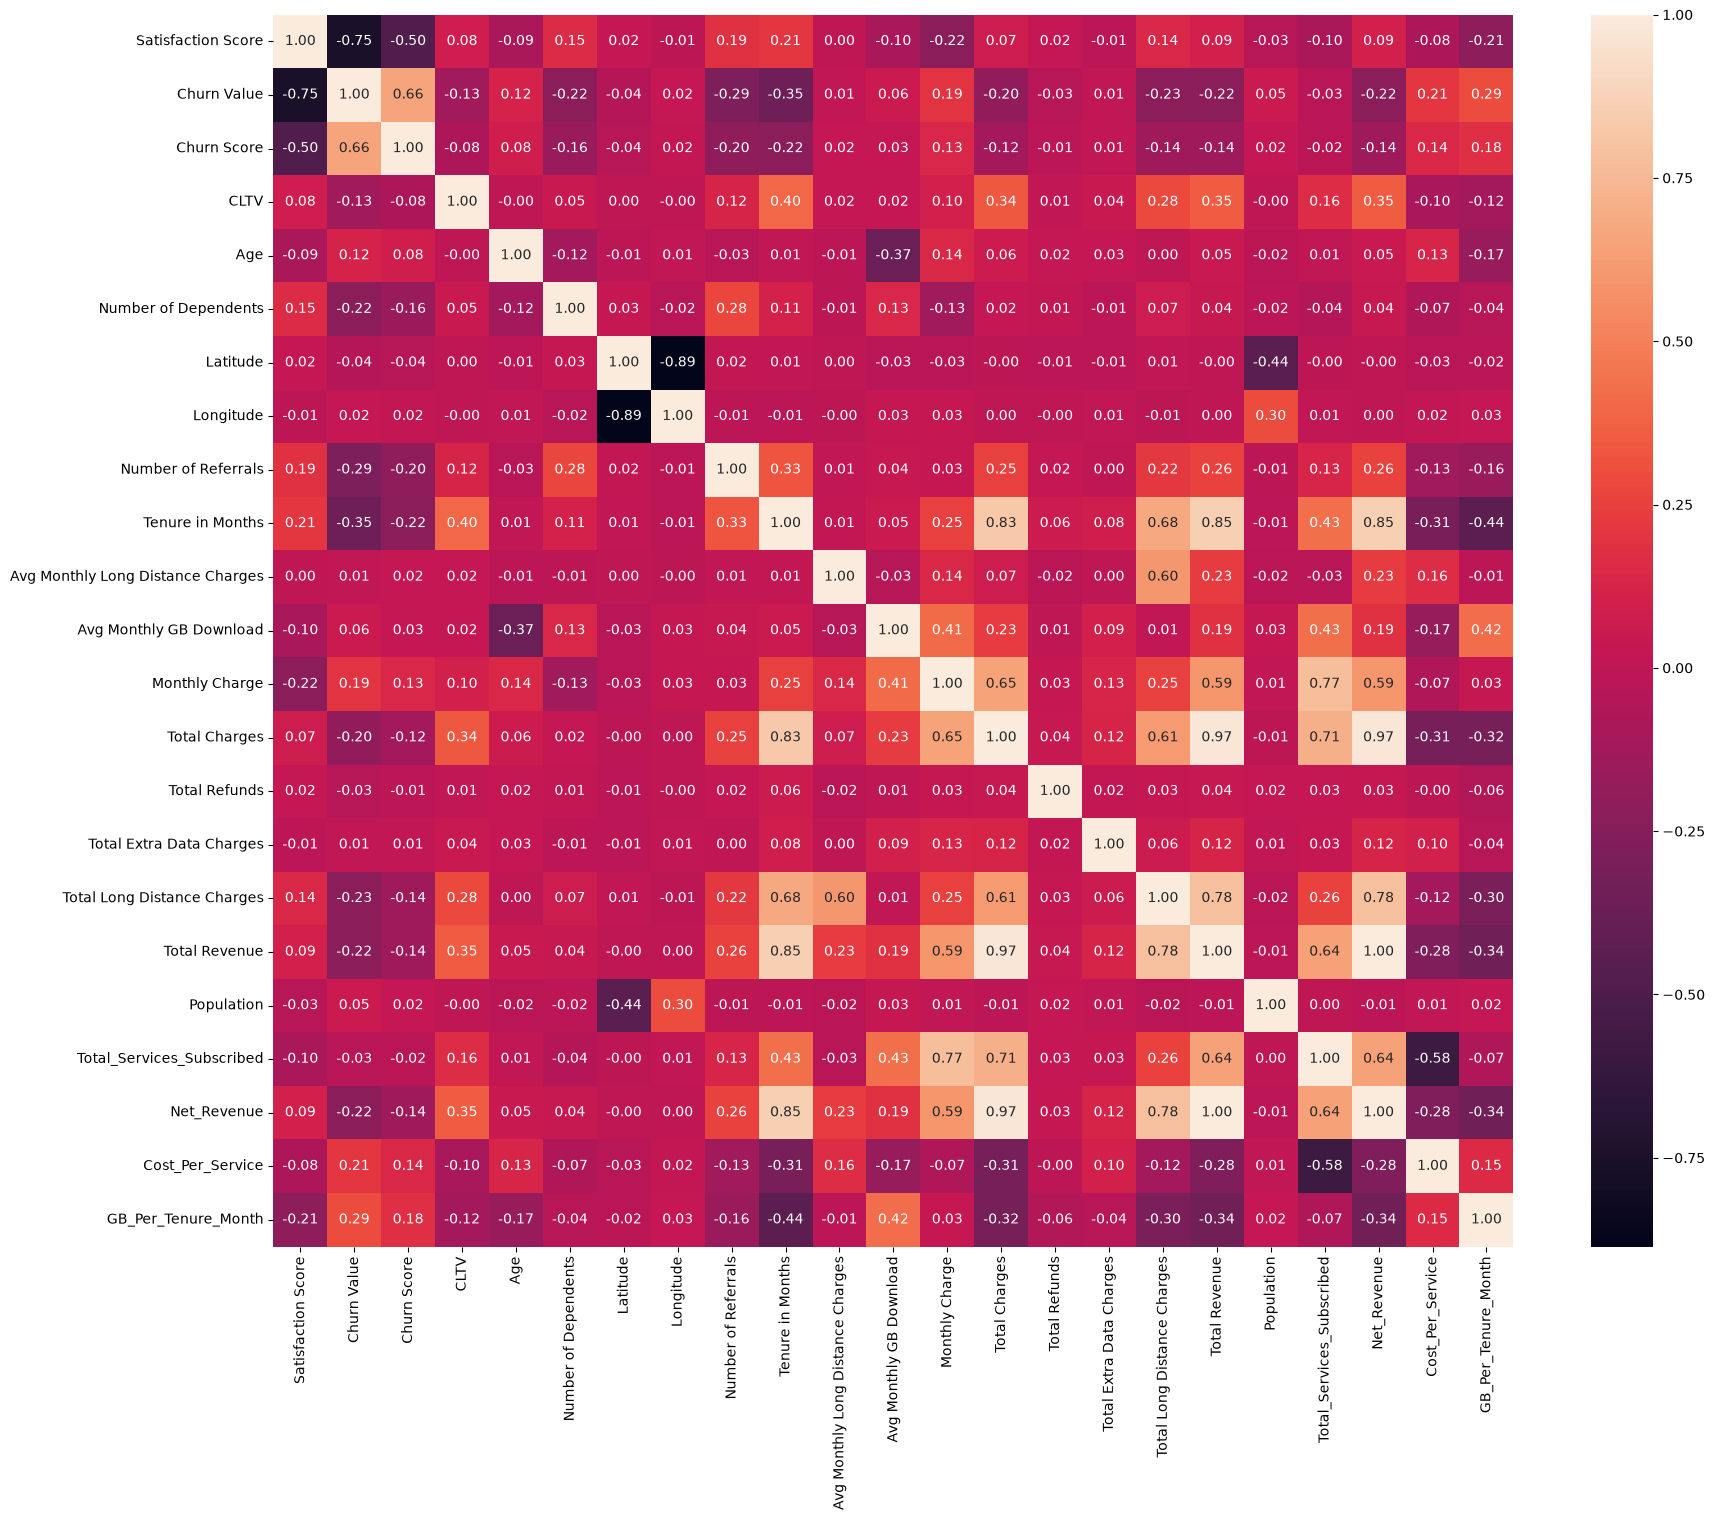

In [94]:
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()


In [95]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
features = [col for col in numeric_cols if col != 'Churn Value']
corr_matrix = df[features].corr().abs()

# هنا علشان نمنع التكرار
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(to_drop)
df = df.drop(columns=to_drop)


['Longitude', 'Total Revenue', 'Net_Revenue']


In [96]:
# اي عمود قيمة واحدة فيه مسيطرة بنسبة 85%+ بيفيد قليل جدا، بنشيله (ما عدا التارجت)
CONSTANT_THRESHOLD = 0.85
near_constant_cols = [
    c for c in df.columns
    if df[c].value_counts(normalize=True, dropna=False).iloc[0] >= CONSTANT_THRESHOLD
    and c != 'Churn Value'
]
print(near_constant_cols)
df = df.drop(columns=near_constant_cols)


['Phone Service', 'Total Refunds', 'Total Extra Data Charges']


In [97]:
# نحفظ نسخة نضيفة ومفهومة هنا قبل الـ Encoding، عشان دي الي هتتستخدم في SQL و Dashboard
df.to_csv(DATA_DIR + 'telco_final.csv', index=False)
df.shape


(7043, 49)

# 7-Encoding

In [98]:
# دول IDs ومعلومات مكررة مع التارجت نفسه، مش هتفيد كـ features لموديل
leak_cols = ['Customer ID', 'Zip Code', 'City', 'Status ID', 'Location ID', 'Service ID',
             'Customer Status', 'Churn Label', 'Churn Category', 'Churn Reason',
             'Churn Score']
df_ml = df.drop(columns=[c for c in leak_cols if c in df.columns])


In [99]:
X = df_ml.drop(columns=['Churn Value'])
Y = df_ml['Churn Value']


In [100]:
X.select_dtypes(include='object').nunique().sort_values(ascending=False)


C:\Users\moham\AppData\Local\Temp\ipykernel_31596\1528514215.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include='object').nunique().sort_values(ascending=False)


Offer                     6
Internet Type             4
Contract                  3
Payment Method            3
Gender                    2
Dependents                2
Married                   2
Senior Citizen            2
Under 30                  2
Internet Service          2
Online Security           2
Multiple Lines            2
Referred a Friend         2
Device Protection Plan    2
Online Backup             2
Premium Tech Support      2
Streaming TV              2
Streaming Music           2
Streaming Movies          2
Unlimited Data            2
Paperless Billing         2
dtype: int64

In [101]:
cat_cols = [c for c in X.select_dtypes(include='object').columns if X[c].nunique() <= 10]
X = pd.get_dummies(X, columns=cat_cols)
X.shape


C:\Users\moham\AppData\Local\Temp\ipykernel_31596\718318282.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in X.select_dtypes(include='object').columns if X[c].nunique() <= 10]


(7043, 66)

# 8-Train/Test Split

In [102]:
# اكتشفت ان الافضل اعمل Train/Test Split قبل Normalization علشان اتجنب مشكلة Data Leakage
# لو عملت fit_transform على كل الداتا، الـ Scaler هيحسب min والـ max باستخدام بيانات الـ test
# وده معناه الموديل شاف جزء من بيانات التيست بشكل غير مباشر
# فالصح استخدم fit_transform على الـ Train بس، و transform بس على الـ Test بنفس الـ Scaler


In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5634, 66)
X_test shape: (1409, 66)


# 9-Normalization

In [104]:
scaler = MinMaxScaler()

numeric_cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])


In [105]:
X_train.head()


,Satisfaction Score,CLTV,Age,Number of Dependents,Latitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Long Distance Charges,Population,Total_Services_Subscribed,Cost_Per_Service,GB_Per_Tenure_Month,Gender_Female,Gender_Male,Under 30_No,Under 30_Yes,Senior Citizen_No,Senior Citizen_Yes,Married_No,Married_Yes,Dependents_No,Dependents_Yes,Referred a Friend_No,Referred a Friend_Yes,Offer_No Offer,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,Offer_Offer E,Multiple Lines_No,Multiple Lines_Yes,Internet Service_No,Internet Service_Yes,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet Service,Online Security_No,Online Security_Yes,Online Backup_No,Online Backup_Yes,Device Protection Plan_No,Device Protection Plan_Yes,Premium Tech Support_No,Premium Tech Support_Yes,Streaming TV_No,Streaming TV_Yes,Streaming Movies_No,Streaming Movies_Yes,Streaming Music_No,Streaming Music_Yes,Unlimited Data_No,Unlimited Data_Yes,Contract_Month-to-Month,Contract_One Year,Contract_Two Year,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check
4626,1.0,0.393238,0.393443,0.000000,0.979544,0.000000,0.211268,0.115823,0.063492,0.366766,0.098840,0.032257,0.009276,0.250,0.168172,0.007470,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,True,False,True,False,True,False,False,True,False,False,True,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False,True,False,True,False,False
4192,0.5,0.869662,0.704918,0.222222,0.549124,0.000000,0.154930,0.339268,0.285714,0.865768,0.145032,0.070865,0.462358,0.750,0.120140,0.043956,True,False,True,False,True,False,True,False,False,True,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,True,False,False,False,True,True,False,False
5457,0.5,0.730872,0.213115,0.000000,0.572376,0.000000,0.000000,0.983997,0.269841,0.303892,0.003485,0.017128,0.045722,0.250,0.138422,0.269841,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False,True,False,True,False,False,True,True,False,True,False,True,False,False,True,True,False,False,True,False,False,True,False
4717,0.5,0.726423,0.081967,0.000000,0.145407,0.727273,0.802817,0.539908,0.841270,0.497505,0.456202,0.545075,0.804731,0.625,0.068532,0.028518,True,False,False,True,True,False,False,True,True,False,False,True,True,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True,True,False,True,False,False,True,True,False,False,True,False,True,False,True,False,True,False,False,True,True,False,False
4673,0.5,0.502891,0.491803,0.333333,0.149719,0.181818,0.028169,0.383677,0.349206,0.613273,0.025675,0.020035,0.670469,0.375,0.190367,0.174603,True,False,True,False,True,False,False,True,False,True,False,True,True,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False,False,True,True,False,False,True,True,False,True,False,True,False,False,True,True,False,False,False,True,True,False,False
